In [1]:
import pandas as pd
import wandb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Optional

In [2]:
table_raw = pd.read_json("./paper_table.json")

# Load and examine the paper table structure
print("Paper table shape:", table_raw.shape)
print("\nColumns:", table_raw.columns.tolist())
print("\nUnique environments:", table_raw['Environment'].unique())
print("\nUnique dataset types:", table_raw['Dataset Type'].unique())

# Get all algorithm columns (excluding metadata columns)
metadata_cols = ['Environment', 'Dataset Type', 'Dataset']
algorithm_cols = [col for col in table_raw.columns if col not in metadata_cols]
print(f"\nAlgorithms in paper: {algorithm_cols}")

# Show a sample of the data
print("\nSample data:")
print(table_raw.head())

Paper table shape: (67, 9)

Columns: ['Environment', 'Dataset Type', 'Dataset', 'GCBC', 'GCIVL', 'GCIQL', 'QRL', 'CRL', 'HIQL']

Unique environments: ['pointmaze' 'antmaze' 'humanoidmaze' 'antsoccer' 'visual-antmaze'
 'visual-humanoidmaze' 'cube' 'scene' 'puzzle' 'visual-cube'
 'visual-scene' 'visual-puzzle' 'powderworld']

Unique dataset types: ['navigate' 'stitch' 'explore' 'play']

Algorithms in paper: ['GCBC', 'GCIVL', 'GCIQL', 'QRL', 'CRL', 'HIQL']

Sample data:
  Environment Dataset Type                         Dataset     GCBC    GCIVL  \
0   pointmaze     navigate    pointmaze-medium-navigate-v0    9 ± 6   63 ± 6   
1   pointmaze     navigate     pointmaze-large-navigate-v0   29 ± 6   45 ± 5   
2   pointmaze     navigate     pointmaze-giant-navigate-v0    1 ± 2    0 ± 0   
3   pointmaze     navigate  pointmaze-teleport-navigate-v0   25 ± 3   45 ± 3   
4   pointmaze       stitch      pointmaze-medium-stitch-v0  23 ± 18  70 ± 14   

    GCIQL      QRL      CRL    HIQL  
0  53 ± 8

In [3]:
# Initialize wandb API
api = wandb.Api()

# Helper functions for data processing
def parse_metric_string(metric_str):
    """Parse strings like '50 ± 4' into mean and std"""
    if isinstance(metric_str, str) and '±' in metric_str:
        parts = metric_str.split('±')
        mean = float(parts[0].strip())
        std = float(parts[1].strip())
        return mean, std
    return None, None

def get_wandb_runs(entity: str, project: str, filters: Optional[Dict] = None):
    """Download runs from wandb project"""
    print(f"Downloading runs from {entity}/{project}...")
    runs = api.runs(f"{entity}/{project}", filters=filters)
    print(f"Found {len(runs)} runs")
    return runs

In [4]:
# Function to download and organize wandb metrics
def download_wandb_metrics(entity: str, project: str, 
                          target_metrics: Optional[List[str]] = None,
                          filters: Optional[Dict] = None) -> pd.DataFrame:
    """
    Download metrics from wandb and organize them for comparison
    
    Args:
        entity: wandb entity name
        project: wandb project name
        target_metrics: list of metric names to extract (e.g., ['eval/success_rate'])
        filters: wandb API filters
    
    Returns:
        DataFrame with organized metrics
    """
    runs = get_wandb_runs(entity, project, filters)

    
    data = []
    for run in runs:
        # Get run metadata
        config = run.config
        summary = run.summary
        
        # Extract relevant information from run name and config
        run_data = {
            'run_id': run.id,
            'run_name': run.name,
            'state': run.state,
            'created_at': run.created_at,
        }
        
        # Add config parameters
        for key, value in config.items():
            run_data[f'config_{key}'] = value
            
        # Add summary metrics
        if target_metrics:
            for metric in target_metrics:
                if metric in summary:
                    run_data[metric] = summary[metric]
        else:
            # Add all summary metrics if no specific metrics requested
            for key, value in summary._json_dict.items():
                if isinstance(value, (int, float)):
                    run_data[f'metric_{key}'] = value
                    
        data.append(run_data)
    
    return pd.DataFrame(data)

# Function to extract dataset and algorithm info from run names/configs
def parse_run_info(wandb_df: pd.DataFrame, target_metric: str = 'evaluation/overall_success') -> pd.DataFrame:
    """
    Parse wandb run information to match table_raw structure.
    Transforms wandb runs into the same format as paper table with algorithm columns.
    """
    parsed_df = wandb_df.copy()
    
    # Extract algorithm from run name (case insensitive)
    parsed_df['algorithm'] = parsed_df['run_name'].str.extract(r'_(GCBC|GCIVL|GCIQL|QRL|CRL|HIQL)_', expand=False)
    
    # Use config_env_name if available (this contains the full environment name)
    if 'config_env_name' in parsed_df.columns:
        parsed_df['Dataset'] = parsed_df['config_env_name']
    else:
        # Fallback to extracting from run name
        parsed_df['Dataset'] = parsed_df['run_name'].str.extract(r'^([^_]+)', expand=False)
    
    # Extract environment base name and components
    if 'Dataset' in parsed_df.columns:
        # Remove -v0 suffix for processing
        parsed_df['dataset_base'] = parsed_df['Dataset'].str.replace(r'-v\d+$', '', regex=True)
        
        # Extract environment type (base name)
        env_pattern = r'^(puzzle|humanoidmaze|antmaze|pointmaze|scene|cube|powderworld|antsoccer|visual-antmaze|visual-humanoidmaze|visual-cube|visual-scene|visual-puzzle)'
        parsed_df['Environment'] = parsed_df['dataset_base'].str.extract(env_pattern, expand=False)
        
        # Extract dataset type from the end of the name
        type_pattern = r'-(navigate|stitch|explore|play|noisy)$'
        extracted_type = parsed_df['dataset_base'].str.extract(type_pattern, expand=False)
        
        # Map 'noisy' to 'play' to match paper table format, or use extracted type
        parsed_df['Dataset Type'] = extracted_type.replace('noisy', 'play').fillna('play')
    
    # Convert metric values to percentages (multiply by 100) to match paper table scale
    if target_metric in parsed_df.columns:
        parsed_df['metric_value'] = parsed_df[target_metric] * 100
    
    # Group by Environment, Dataset Type, Dataset and algorithm, then aggregate
    if 'algorithm' in parsed_df.columns and 'metric_value' in parsed_df.columns:
        # Group and calculate mean for each algorithm
        grouped = parsed_df.groupby(['Environment', 'Dataset Type', 'Dataset', 'algorithm'])['metric_value'].mean().reset_index()
        
        # Pivot to create algorithm columns like in paper table
        result = grouped.pivot_table(
            index=['Environment', 'Dataset Type', 'Dataset'], 
            columns='algorithm', 
            values='metric_value',
            fill_value=None
        ).reset_index()
        
        # Flatten column names and ensure all algorithm columns exist
        result.columns.name = None
        algorithm_cols = ['GCBC', 'GCIVL', 'GCIQL', 'QRL', 'CRL', 'HIQL']
        
        # Add missing algorithm columns
        for col in algorithm_cols:
            if col.upper() not in [c.upper() for c in result.columns]:
                result[col] = None
        
        # Rename algorithm columns to match paper table (uppercase)
        col_mapping = {}
        for col in result.columns:
            if col.upper() in [a.upper() for a in algorithm_cols]:
                col_mapping[col] = col.upper()
        result = result.rename(columns=col_mapping)
        
        # Reorder columns to match paper table
        final_cols = ['Environment', 'Dataset Type', 'Dataset'] + algorithm_cols
        result = result.reindex(columns=final_cols)
        
        return result
    
    # Fallback: return original structure if parsing fails
    return parsed_df

In [25]:
# Function to compare wandb metrics with paper table
def compare_metrics(wandb_df: pd.DataFrame, paper_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compare wandb metrics with paper table metrics.
    Both dataframes should have the same structure with algorithm columns.
    
    Args:
        wandb_df: DataFrame with wandb metrics (same structure as paper table)
        paper_df: DataFrame with paper table metrics  
        
    Returns:
        DataFrame with comparison results
    """
    algorithm_cols = ['GCBC', 'GCIVL', 'GCIQL', 'QRL', 'CRL', 'HIQL']
    
    # Merge on Environment, Dataset Type, Dataset
    merge_cols = ['Environment', 'Dataset Type', 'Dataset']
    comparison = pd.merge(
        wandb_df, 
        paper_df,
        on=merge_cols,
        how='outer',
        suffixes=('_wandb', '_paper')
    )
    
    # Create comparison data for each algorithm
    comparison_results = []
    
    for _, row in comparison.iterrows():
        env = row['Environment']
        dataset_type = row['Dataset Type']
        dataset = row['Dataset']
        
        for algo in algorithm_cols:
            wandb_col = f'{algo}_wandb' if f'{algo}_wandb' in row else algo
            paper_col = f'{algo}_paper' if f'{algo}_paper' in row else algo
            
            wandb_val = row.get(wandb_col)
            paper_val = row.get(paper_col)
            
            # Parse paper value if it's in "mean ± std" format
            if isinstance(paper_val, str) and '±' in str(paper_val):
                paper_mean, paper_std = parse_metric_string(paper_val)
            elif pd.notna(paper_val):
                paper_mean, paper_std = float(paper_val), None
            else:
                paper_mean, paper_std = None, None
            
            # Skip if both values are missing
            if pd.isna(wandb_val) and paper_mean is None:
                continue
                
            comparison_results.append({
                'Environment': env,
                'Dataset Type': dataset_type,
                'Dataset': dataset,
                'algorithm': algo,
                'wandb_mean': wandb_val,
                'paper_mean': paper_mean,
                'paper_std': paper_std,
                'paper_metric': paper_val
            })
    
    result_df = pd.DataFrame(comparison_results)
    
    # Calculate differences
    if len(result_df) > 0:
        result_df['mean_diff'] = result_df['wandb_mean'] - result_df['paper_mean']
        result_df['relative_diff'] = (result_df['mean_diff'] / result_df['paper_mean'] * 100).replace([np.inf, -np.inf], np.nan)
        result_df['std_diff'] = result_df['mean_diff'] / result_df['paper_std']
        result_df['relative_std'] = result_df["paper_std"] / result_df["paper_mean"]
    
    return result_df

# Function to create visualizations
def plot_comparison(comparison_df: pd.DataFrame, save_plots: bool = False):
    """Create visualizations comparing wandb vs paper metrics"""
    
    # Filter out rows with missing data
    valid_data = comparison_df.dropna(subset=['wandb_mean', 'paper_mean'])
    
    if len(valid_data) == 0:
        print("No valid data for comparison!")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Scatter plot: wandb vs paper means
    ax1 = axes[0, 0]
    ax1.errorbar(valid_data['paper_mean'], valid_data['wandb_mean'], xerr=valid_data['paper_std'], alpha=0.6, marker='o', linestyle='None')
    ax1.plot([0, max(valid_data['paper_mean'].max(), valid_data['wandb_mean'].max())],
             [0, max(valid_data['paper_mean'].max(), valid_data['wandb_mean'].max())], 
             'r--', label='y=x')
    ax1.set_xlabel('Paper Mean')
    ax1.set_ylabel('Baseline Mean')
    ax1.set_title('Baseline vs Paper Means')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Histogram of differences
    ax2 = axes[0, 1]
    std_diff = [d for d in valid_data['std_diff'] if not np.isinf(d) and not pd.isna(d)]
    #ax2.hist(valid_data['std_diff'].dropna(), bins=20, alpha=0.7)
    ax2.hist(std_diff, bins=None, alpha=0.7)
    ax2.axvline(0, color='red', linestyle='--', label='No difference')
    ax2.set_xlabel('Standard Deviation Difference (Baseline - Paper)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Standard Deviation Differences')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Differences in std by algorithm
    ax3 = axes[1, 0]
    if 'algorithm' in valid_data.columns:
        for algo in valid_data['algorithm'].unique():
            if pd.notna(algo):
                algo_data = valid_data[valid_data['algorithm'] == algo]
                ax3.scatter(algo_data['paper_mean'], algo_data['std_diff'], 
                          label=algo.upper(), alpha=0.7)
    ax3.axhline(0, color='red', linestyle='-', alpha=0.5)
    ax3.axhline(3, color='red', linestyle='--', alpha=0.5)
    ax3.axhline(-3, color='red', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Paper Mean')
    ax3.set_ylabel('Difference in Std')
    ax3.set_title('Differences in Std by Algorithm')
    if 'algorithm' in valid_data.columns:
        ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Standard deviation comparison (wandb doesn't have std, so show distribution)
    ax4 = axes[1, 1]
    # Show distribution of wandb means vs paper stds
    if 'paper_std' in valid_data.columns:
        std_valid = valid_data.dropna(subset=['paper_std'])
        if len(std_valid) > 0:
            ax4.scatter(std_valid['relative_std'], np.abs(std_valid['relative_diff']), alpha=0.6, c='blue', label='Relative Std vs Relative Difference')
            ax4.set_xlabel('Relative Std')
            ax4.set_ylabel('Relative Difference')
            ax4.set_title('Relative Std vs Relative Difference')
            #ax4.legend()
            ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('baseline_vs_paper_comparison.png', dpi=300, bbox_inches='tight')
        print("Plot saved as 'baseline_vs_paper_comparison.png'")

    plt.show()
    
    # Summary statistics
    print("\\n=== COMPARISON SUMMARY ===")
    print(f"Total comparisons: {len(valid_data)}")
    print(f"Mean absolute difference: {valid_data['mean_diff'].abs().mean():.2f}")
    print(f"Mean relative difference: {valid_data['relative_diff'].abs().mean():.2f}%")
    print(f"Correlation coefficient: {valid_data['wandb_mean'].corr(valid_data['paper_mean']):.3f}")
    
    return fig

## Step 1: Configure your wandb settings

Before running the comparison, you need to specify your wandb project details.

In [6]:
# Configure your wandb project settings
WANDB_ENTITY = "mpcdf"  # Replace with your wandb entity/username
WANDB_PROJECT = "OGBench"  # Replace with your project name

# Specify which metric to compare (adjust based on your wandb logs)
TARGET_METRIC = "evaluation/overall_success"  # Common metric name, adjust as needed

# Optional: Add filters for wandb runs (e.g., only completed runs)
WANDB_FILTERS = {"state": "finished", "tags": "baseline"}  # Only get finished runs

print(f"Configured to download from: {WANDB_ENTITY}/{WANDB_PROJECT}")
print(f"Target metric: {TARGET_METRIC}")
print(f"Filters: {WANDB_FILTERS}")

Configured to download from: mpcdf/OGBench
Target metric: evaluation/overall_success
Filters: {'state': 'finished', 'tags': 'baseline'}


## Step 2: Download wandb metrics

This will download your wandb runs and extract the metrics.

In [7]:
# Download wandb metrics
try:
    wandb_df = download_wandb_metrics(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        target_metrics=[TARGET_METRIC],
        filters=WANDB_FILTERS
    )
    
    print(f"Downloaded {len(wandb_df)} runs from wandb")
    print(f"Columns: {wandb_df.columns.tolist()}")
    
    # Parse run information to match table_raw structure
    wandb_parsed = parse_run_info(wandb_df, TARGET_METRIC)
    
    print("\\nParsed run information:")
    print(f"Shape: {wandb_parsed.shape}")
    print(f"Columns: {wandb_parsed.columns.tolist()}")
    print(f"Unique environments: {wandb_parsed['Environment'].dropna().unique()}")
    print(f"Unique dataset types: {wandb_parsed['Dataset Type'].dropna().unique()}")
    
    # Show sample data
    print("\\nSample wandb data:")
    display(wandb_parsed.head())

except Exception as e:
    print(f"Error downloading wandb data: {e}")
    print("Please check your wandb configuration and make sure you have the right entity/project names")
    wandb_parsed = None

Found 70 runs
Downloaded 70 runs from wandb
Columns: ['run_id', 'run_name', 'state', 'created_at', 'config_?', 'config_v', 'config_pdb', 'config_help', 'config_seed', 'config_agent', 'config_helpxml', 'config_log_dir', 'config_env_name', 'config_helpfull', 'config_save_dir', 'config_helpshort', 'config_run_group', 'config_verbosity', 'config_eval_tasks', 'config_dataset_dir', 'config_eval_on_cpu', 'config_logtostderr', 'config_test_srcdir', 'config_test_tmpdir', 'config_train_steps', 'config_log_interval', 'config_profile_file', 'config_restore_path', 'config_run_with_pdb', 'config_eval_episodes', 'config_eval_gaussian', 'config_eval_interval', 'config_logger_levels', 'config_restore_epoch', 'config_save_interval', 'config_video_episodes', 'config_alsologtostderr', 'config_only_check_args', 'config_pdb_post_mortem', 'config_stderrthreshold', 'config_xml_output_file', 'config_eval_temperature', 'config_test_random_seed', 'config_video_frame_skip', 'config_showprefixforinfo', 'config_che

,Environment,Dataset Type,Dataset,GCBC,GCIVL,GCIQL,QRL,CRL,HIQL
0,antmaze,explore,antmaze-large-explore-v0,None,None,1.2,None,0.0,None
1,antmaze,explore,antmaze-medium-explore-v0,None,None,9.6,None,3.6,None
2,antmaze,explore,antmaze-teleport-explore-v0,None,None,5.2,None,9.6,None
3,antmaze,navigate,antmaze-giant-navigate-v0,None,None,0.4,None,19.2,None
4,antmaze,navigate,antmaze-large-navigate-v0,None,None,30.8,None,73.6,None


## Step 3: Compare metrics

Now let's compare the wandb metrics with the paper table.

Comparison completed. Found 412 comparison points
\n=== DETAILED COMPARISON ===
\nValid comparisons: 60


,Environment,Dataset Type,algorithm,Dataset,wandb_mean,paper_mean,mean_diff,relative_diff,std_diff
2,antmaze,explore,GCIQL,antmaze-large-explore-v0,1.2,0.0,1.2,NaN,inf
4,antmaze,explore,CRL,antmaze-large-explore-v0,0.0,0.0,0.0,NaN,NaN
8,antmaze,explore,GCIQL,antmaze-medium-explore-v0,9.6,13.0,-3.4,-26.15,-1.70
10,antmaze,explore,CRL,antmaze-medium-explore-v0,3.6,3.0,0.6,20.00,0.30
14,antmaze,explore,GCIQL,antmaze-teleport-explore-v0,5.2,7.0,-1.8,-25.71,-0.60
16,antmaze,explore,CRL,antmaze-teleport-explore-v0,9.6,20.0,-10.4,-52.00,-5.20
20,antmaze,navigate,GCIQL,antmaze-giant-navigate-v0,0.4,0.0,0.4,NaN,inf
22,antmaze,navigate,CRL,antmaze-giant-navigate-v0,19.2,16.0,3.2,20.00,1.07
26,antmaze,navigate,GCIQL,antmaze-large-navigate-v0,30.8,34.0,-3.2,-9.41,-0.80
28,antmaze,navigate,CRL,antmaze-large-navigate-v0,73.6,83.0,-9.4,-11.33,-2.35


Plot saved as 'baseline_vs_paper_comparison.png'


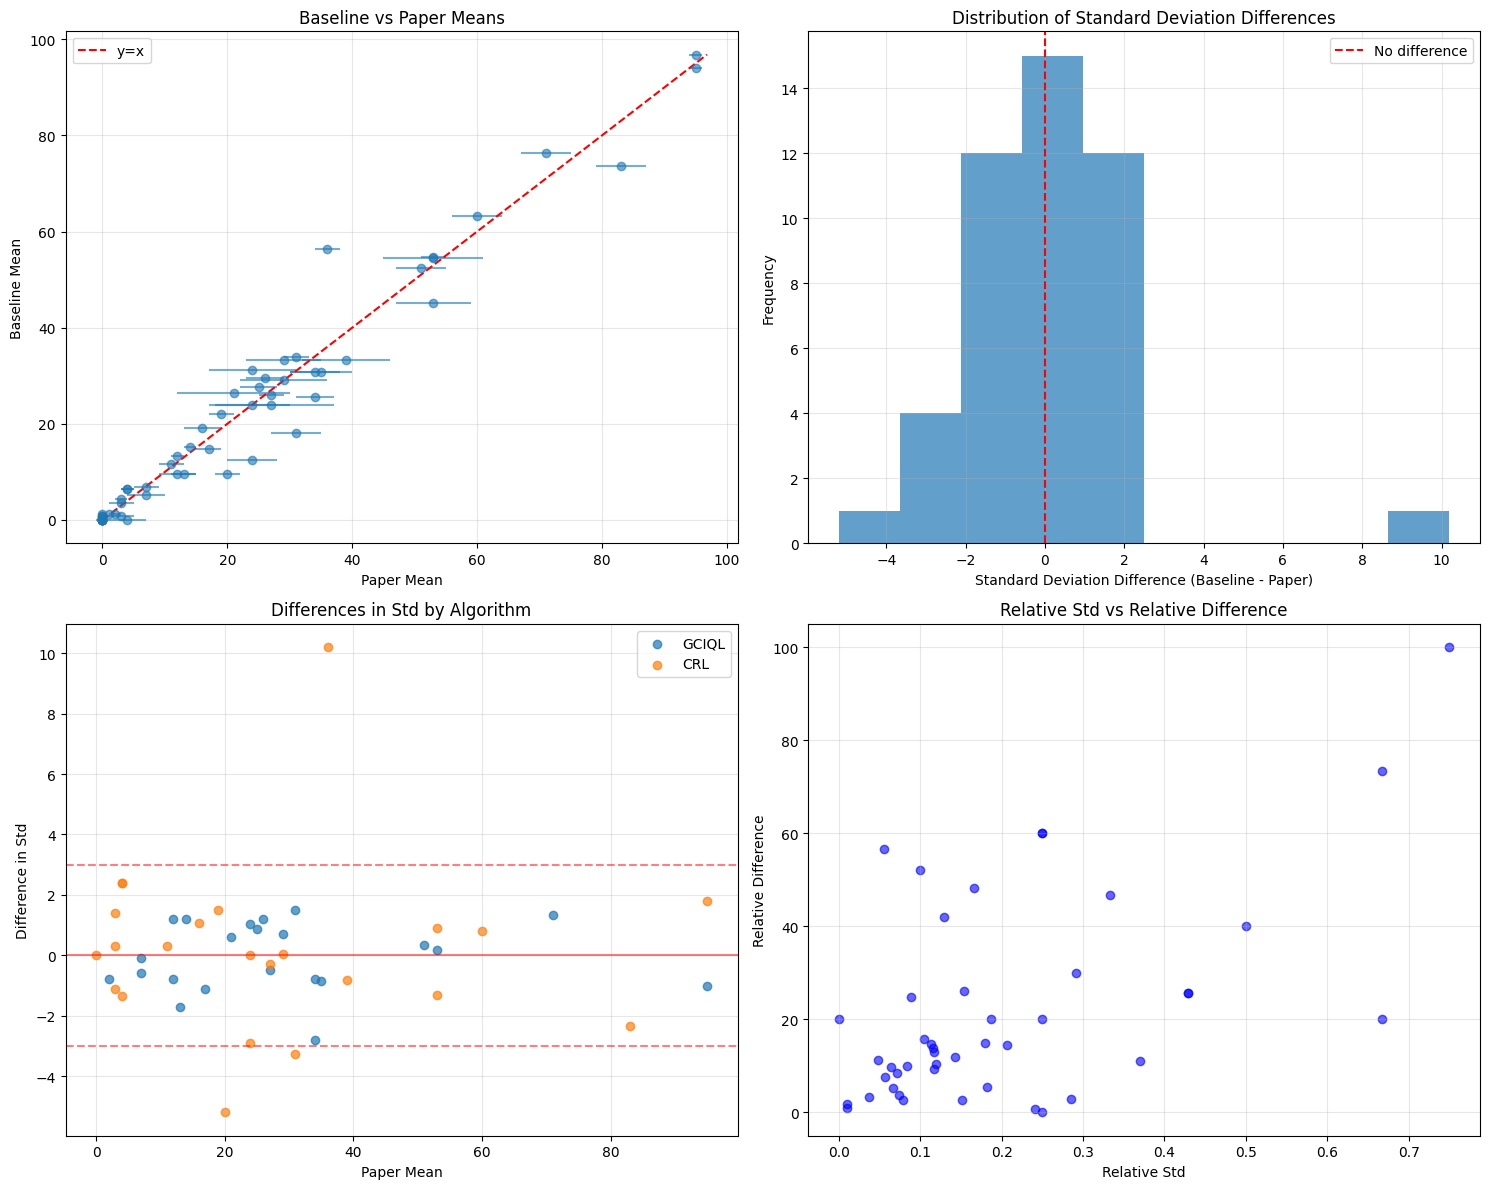

\n=== COMPARISON SUMMARY ===
Total comparisons: 60
Mean absolute difference: 2.96
Mean relative difference: 22.17%
Correlation coefficient: 0.980


In [26]:
if wandb_parsed is not None:
    # Perform comparison
    comparison = compare_metrics(
        wandb_df=wandb_parsed,
        paper_df=table_raw
    )
    
    print(f"Comparison completed. Found {len(comparison)} comparison points")
    
    # Show detailed comparison results
    print("\\n=== DETAILED COMPARISON ===")
    
    # Filter to show only rows where we have both wandb and paper data
    valid_comparisons = comparison.dropna(subset=['wandb_mean', 'paper_mean'])
    
    print(f"\\nValid comparisons: {len(valid_comparisons)}")
    
    # Show the comparison table
    display_cols = ['Environment', 'Dataset Type', 'algorithm', 'Dataset', 'wandb_mean', 'paper_mean', 
                    'mean_diff', 'relative_diff', 'std_diff']
    display_data = valid_comparisons[display_cols].round(2)
    display(display_data.head(10))
    
    # Create visualizations
    plot_comparison(comparison, save_plots=True)
    
else:
    print("Skipping comparison due to wandb download error")

In [9]:
for row in valid_comparisons.itertuples():
    if pd.isna(row.std_diff) or np.isinf(row.std_diff):
        continue
    if np.abs(row.std_diff) > 3:
        print(row.Dataset, row.algorithm, row.wandb_mean, row.paper_mean, row.paper_std, row.std_diff)

antmaze-teleport-explore-v0 CRL 9.6 20.0 2.0 -5.2
antmaze-teleport-stitch-v0 CRL 18.0 31.0 4.0 -3.25
humanoidmaze-medium-stitch-v0 CRL 56.39999999999999 36.0 2.0 10.199999999999996
